<a href="https://colab.research.google.com/github/zawarhussainn/Introduction-to-AI-Assignment-2/blob/main/HotDog_Classifier_Zawar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import random
print("Libraries loaded successfully!")
print("TensorFlow version:", tf.__version__)

Libraries loaded successfully!
TensorFlow version: 2.20.0


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dansbecker/hot-dog-not-hot-dog")

print("Path to dataset files:", path)

100%|██████████| 89.3M/89.3M [00:00<00:00, 244MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/dansbecker/hot-dog-not-hot-dog/versions/5


In [6]:
# Define paths (CHANGE THIS to your actual path)
train_path = os.path.join(path, "train")
test_path = os.path.join(path, "test")
# Count images
hot_dog_count = len(os.listdir(os.path.join(train_path, "hot_dog")))
not_hot_dog_count = len(os.listdir(os.path.join(train_path, "not_hot_dog")))
print(f"Hot dog images: {hot_dog_count}")
print(f"Not hot dog images: {not_hot_dog_count}")
# YOUR CODE HERE: Print the number of test images
# Hint: Look at the code above and modify it for test_path
test_hot_dog_count = len(os.listdir(os.path.join(test_path, "hot_dog")))
test_not_hot_dog_count = len(os.listdir(os.path.join(test_path, "not_hot_dog")))
print(f"Test hot dog images: {test_hot_dog_count}")
print(f"Test not hot dog images: {test_not_hot_dog_count}")

Hot dog images: 249
Not hot dog images: 249
Test hot dog images: 250
Test not hot dog images: 250


Shape of one image: (512, 512, 3)


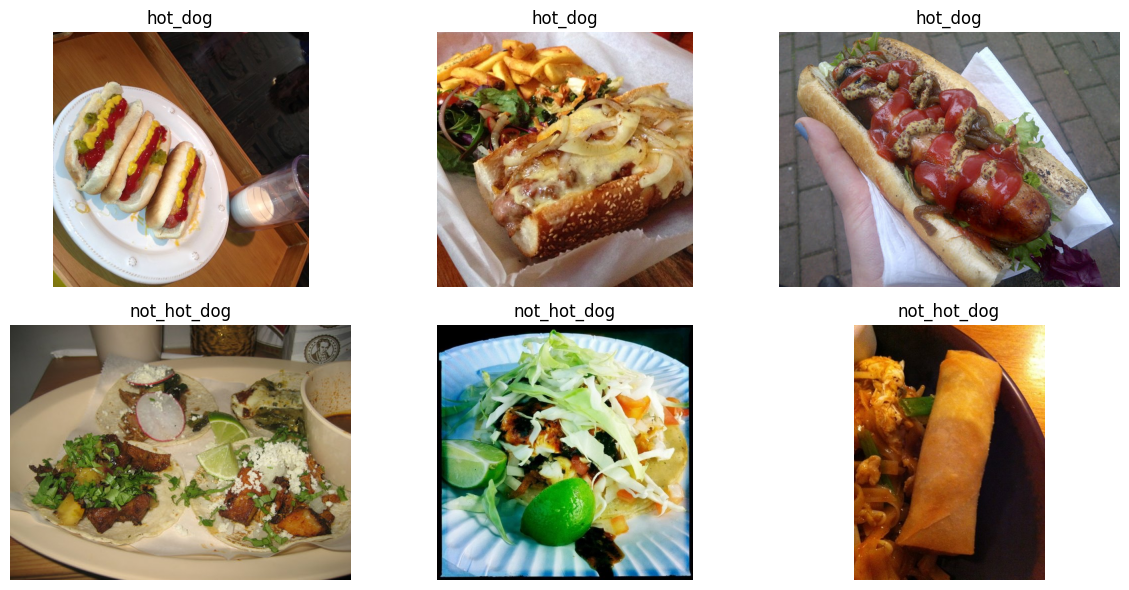

In [9]:
# Display 6 random images
plt.figure(figsize=(12, 6))
for i in range(6):
    # Pick random class
    class_name = random.choice(["hot_dog", "not_hot_dog"])
    class_path = os.path.join(train_path, class_name)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)
    # Load and show image
    img = plt.imread(img_path)
    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

    # YOUR CODE HERE: Print the shape (height, width, channels) of one
    # image. Hint: Use img.shape after loading an image
    if i == 0: # Print shape for the first image only
        print(f"Shape of one image: {img.shape}")

plt.tight_layout()
plt.show()

In [11]:
# Set image size (YOUR CHOICE: 64x64 is faster, 128x128 is more accurate)
IMG_HEIGHT = 64
IMG_WIDTH = 64
BATCH_SIZE = 32
# Create generators with automatic labeling
train_datagen = ImageDataGenerator(
    rescale=1./255, # Normalize pixel values from 0-255 to 0-1
    validation_split=0.2 # Use 20% of training data for validation
)
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary', # Binary classification (hot dog vs not)
    subset='training' # Training set (80% of data)
)
validation_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation' # Validation set (20% of data)
)
# YOUR CODE HERE: Print the class labels
#
# Hint: Print train_generator.class_indices
print(train_generator.class_indices)

Found 400 images belonging to 2 classes.
Found 98 images belonging to 2 classes.
{'hot_dog': 0, 'not_hot_dog': 1}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,581,313 (6.03 MB)

 Trainable params: 1,581,313 (6.03 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.4800 - loss: 1.3457 - val_accuracy: 0.5000 - val_loss: 1.0189
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.5325 - loss: 0.7464 - val_accuracy: 0.5918 - val_loss: 0.6935
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.6400 - loss: 0.6375 - val_accuracy: 0.5816 - val_loss: 0.6832
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.6050 - loss: 0.7128 - val_accuracy: 0.5918 - val_loss: 0.6880
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.6975 - loss: 0.5796 - val_accuracy: 0.5612 - val_loss: 0.7217
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.6700 - loss: 0.5737 - val_accuracy: 0.5204 - val_loss: 0.7323
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.7600 - loss: 0.5094 - val_accuracy: 0.5306 - val_loss: 0.7696
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.7250 - loss: 0.5302 - val_accuracy: 0.5306 - v

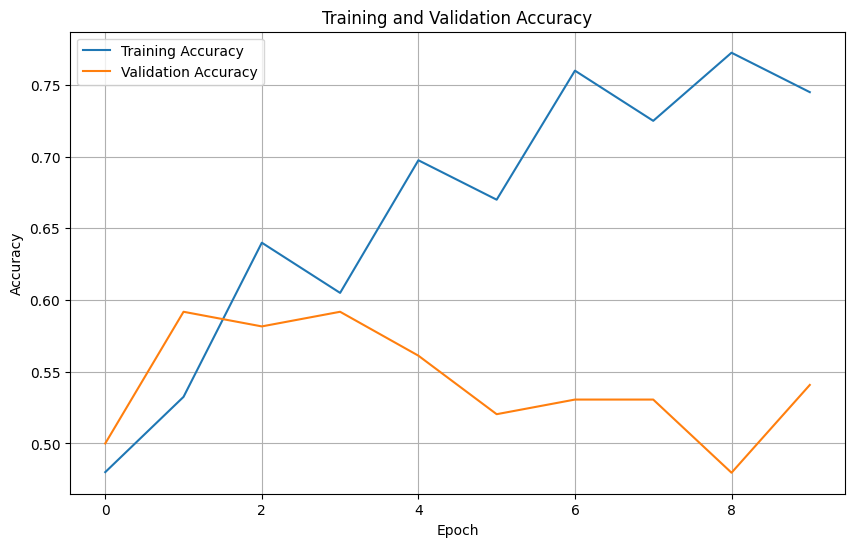

In [17]:
# Build a simple ANN
ann_model = keras.Sequential([
    # Flatten the 2D image into 1D
    layers.Flatten(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    # Dense layers
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Output: probability of "hot dog"
])
# Compile the model
ann_model.compile(optimizer='adam', loss='binary_crossentropy',
                  metrics=['accuracy'])
# Show model summary
ann_model.summary()
# Train for 10 epochs
history_ann = ann_model.fit(train_generator, validation_data=
                            validation_generator, epochs=10)
# YOUR CODE HERE: Plot training vs validation accuracy.
#
#
# Hint: Use
# plt.plot(history_ann.history['XXXX'], label='XXXX')
# plt.plot(history_ann.history['XXXX'], label='XXXX')
plt.figure(figsize=(10, 6))
plt.plot(history_ann.history['accuracy'], label='Training Accuracy')
plt.plot(history_ann.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
cnn_model = keras.Sequential([
    # First Conv layer: 32 filters, 3x3 kernel
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(
        IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),
    # Second Conv layer: 64 filters
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    # Third Conv layer (YOUR TURN): Add 64 filters with 3x3 kernel,
    # followed by Max pooling
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    # Flatten and dense layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
# Compile (copy from ANN)
cnn_model.compile(optimizer='adam', loss='binary_crossentropy',
                  metrics=['accuracy'])
# Train the CNN
history_cnn = cnn_model.fit(train_generator, validation_data=
                            validation_generator, epochs=15)

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 176ms/step - accuracy: 0.5000 - loss: 0.7027 - val_accuracy: 0.5000 - val_loss: 0.6906
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 154ms/step - accuracy: 0.5225 - loss: 0.6904 - val_accuracy: 0.5102 - val_loss: 0.6858
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 153ms/step - accuracy: 0.5575 - loss: 0.6750 - val_accuracy: 0.6122 - val_loss: 0.6765
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 139ms/step - accuracy: 0.6125 - loss: 0.6519 - val_accuracy: 0.6122 - val_loss: 0.6417
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 137ms/step - accuracy: 0.6375 - loss: 0.6246 - val_accuracy: 0.6224 - val_loss: 0.6462
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 190ms/step - accuracy: 0.6525 - loss: 0.6274 - val_accuracy: 0.5714 - val_loss: 0.6933
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 138ms/step - accuracy: 0.6900 - loss: 0.5866 - val_accuracy: 0.5714 - val_loss: 0.6609
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 140ms/step - accuracy: 0.7550 - loss: 0.5351 - val_accuracy: 0.6020 - val_

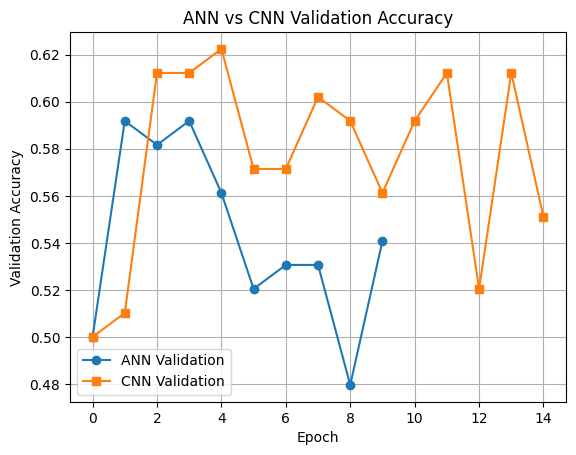

In [20]:
plt.plot(history_ann.history['val_accuracy'], label='ANN Validation', marker='o')
plt.plot(history_cnn.history['val_accuracy'], label='CNN Validation', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.title('ANN vs CNN Validation Accuracy')
plt.grid(True)
plt.show()

In [22]:
from tensorflow.keras import regularizers
# Add dropout of 0.25, 0.25, and 0.5 after each MaxPooling layer
# respectively
improved_model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(
        IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25), # Add dropout
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25), # Add dropout
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5), # Add dropout before output
    layers.Dense(1, activation='sigmoid')
])
# Recompile and Train the improved model (after addressing overfitting
# using dropout)
improved_model.compile(optimizer='adam', loss='binary_crossentropy',
                  metrics=['accuracy'])
history_improved = improved_model.fit(train_generator, validation_data
                            =validation_generator, epochs=15)

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 181ms/step - accuracy: 0.4575 - loss: 0.7227 - val_accuracy: 0.4898 - val_loss: 0.6927
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 154ms/step - accuracy: 0.4875 - loss: 0.6935 - val_accuracy: 0.5102 - val_loss: 0.6932
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 144ms/step - accuracy: 0.5250 - loss: 0.6913 - val_accuracy: 0.5408 - val_loss: 0.6923
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 163ms/step - accuracy: 0.5500 - loss: 0.6899 - val_accuracy: 0.5204 - val_loss: 0.6922
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 172ms/step - accuracy: 0.5000 - loss: 0.6925 - val_accuracy: 0.5102 - val_loss: 0.6914
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 187ms/step - accuracy: 0.5625 - loss: 0.6901 - val_accuracy: 0.5102 - val_loss: 0.6922
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 169ms/step - accuracy: 0.5325 - loss: 0.6867 - val_accuracy: 0.5408 - val_loss: 0.6894
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 154ms/step - accuracy: 0.5525 - loss: 0.6879 - val_accuracy: 0.5714 - val_

In [24]:
augmented_datagen = ImageDataGenerator(
rescale=1./255,
rotation_range=20,
width_shift_range=0.1,
height_shift_range=0.1,
horizontal_flip=True,
validation_split=0.2
)
train_augmented = augmented_datagen.flow_from_directory(
train_path,
target_size=(IMG_HEIGHT, IMG_WIDTH),
batch_size=BATCH_SIZE,
class_mode='binary',
subset='training'
)
# Then retrain the improved model with augmented_datagen
final_model = keras.Sequential([
# Same architecture as improved_model
layers.Conv2D(32, (3, 3), activation='relu', input_shape=(
IMG_HEIGHT, IMG_WIDTH, 3)),
layers.MaxPooling2D((2, 2)),
layers.Dropout(0.25),
layers.Conv2D(64, (3, 3), activation='relu'),
layers.MaxPooling2D((2, 2)),
layers.Dropout(0.25),
layers.Conv2D(64, (3, 3), activation='relu'),
layers.MaxPooling2D((2, 2)),
layers.Flatten(),
layers.Dense(64, activation='relu'),
layers.Dropout(0.5),
layers.Dense(1, activation='sigmoid')
])
final_model.compile(optimizer='adam', loss='binary_crossentropy',
metrics=['accuracy'])
history_final = final_model.fit(train_augmented, validation_data=
validation_generator, epochs=15)

Found 400 images belonging to 2 classes.
Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 233ms/step - accuracy: 0.4675 - loss: 0.7082 - val_accuracy: 0.5000 - val_loss: 0.6929
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 162ms/step - accuracy: 0.5000 - loss: 0.6955 - val_accuracy: 0.5816 - val_loss: 0.6918
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 171ms/step - accuracy: 0.5150 - loss: 0.6906 - val_accuracy: 0.5612 - val_loss: 0.6895
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 160ms/step - accuracy: 0.5450 - loss: 0.6872 - val_accuracy: 0.5510 - val_loss: 0.6857
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 161ms/step - accuracy: 0.5350 - loss: 0.6864 - val_accuracy: 0.5918 - val_loss: 0.6775
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 216ms/step - accuracy: 0.5750 - loss: 0.6805 - val_accuracy: 0.6327 - val_loss: 0.6779
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 180ms/step - accuracy: 0.5425 - loss: 0.6769 - val_accuracy: 0.6020 - val_loss: 0.6724
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 171ms/step - accuracy: 0.6275 - loss: 0.6622 - val_accuracy: 0.5714 - val_

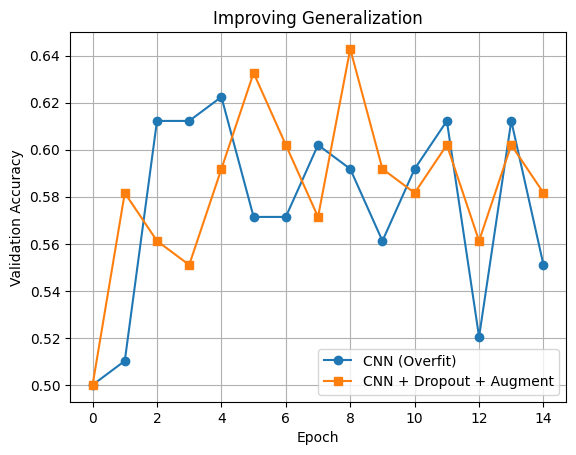

In [27]:
plt.plot(history_cnn.history['val_accuracy'], label='CNN (Overfit)',
marker='o')
plt.plot(history_final.history['val_accuracy'], label='CNN + Dropout + Augment', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.title('Improving Generalization')
plt.grid(True)
plt.show()

Response Status Code: 200
Content-Type: image/webp
Content starts with: b'RIFF\xc8)\x00\x00WEBPVP8 \xbc)\x00\x00\x90\xda\x00\x9d\x01*\xda\x01;\x01>\x9dJ\x9eK%\xa4\xad,\xa7\x95\nQ\xa0\x13\x89M\xce\xb9W'
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
 NOT A HOT DOG! (confidence: 0.51)


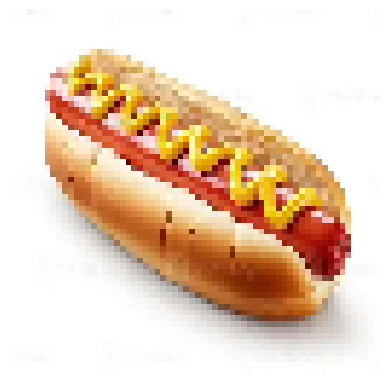

In [43]:
from tensorflow.keras.preprocessing import image
import requests
from io import BytesIO

def predict_image(img_url):
    # Download image with a User-Agent header
    headers = {'User-Agent': 'Mozilla/5.0'}
    response = requests.get(img_url, headers=headers)

    # Diagnostic prints
    print(f"Response Status Code: {response.status_code}")
    print(f"Content-Type: {response.headers.get('Content-Type')}")
    print(f"Content starts with: {response.content[:50]}") # Print first 50 bytes

    # Check if the request was successful before attempting to load image
    if response.status_code != 200:
        print(f"Error: Failed to download image from {img_url}. Status code: {response.status_code}")
        return

    img = image.load_img(BytesIO(response.content), target_size=(
        IMG_HEIGHT, IMG_WIDTH))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # Predict
    prediction = final_model.predict(img_array)[0][0]

    if prediction > 0.5:
        print(f" HOT DOG! (confidence: {prediction:.2f})")
    else:
        print(f" NOT A HOT DOG! (confidence: {1-prediction:.2f})")

    # Show image
    plt.imshow(img)
    plt.axis('off')
    plt.show()

# Test on a hot dog image URL (find one on Google Images)
# Using an example hot dog image URL for demonstration
predict_image("https://tse3.mm.bing.net/th/id/OIP.AhG6YHrGw9dcdDUCC19QqgHaE7?r=0&rs=1&pid=ImgDetMain&o=7&rm=3")

Streaming output truncated to the last 5000 lines.
0: 448x640 1 hot dog, 209.7ms
WARNING ⚠️ Video stream unresponsive, please check your IP camera connection.
WARNING ⚠️ Video stream unresponsive, please check your IP camera connection.
0: 448x640 1 hot dog, 187.2ms
WARNING ⚠️ Video stream unresponsive, please check your IP camera connection.
WARNING ⚠️ Video stream unresponsive, please check your IP camera connection.
0: 448x640 1 hot dog, 161.6ms
WARNING ⚠️ Video stream unresponsive, please check your IP camera connection.
WARNING ⚠️ Video stream unresponsive, please check your IP camera connection.
0: 448x640 1 hot dog, 173.4ms
WARNING ⚠️ Video stream unresponsive, please check your IP camera connection.
WARNING ⚠️ Video stream unresponsive, please check your IP camera connection.
0: 448x640 1 hot dog, 163.4ms
WARNING ⚠️ Video stream unresponsive, please check your IP camera connection.
WARNING ⚠️ Video stream unresponsive, please check your IP camera connection.
WARNING ⚠️ Video st

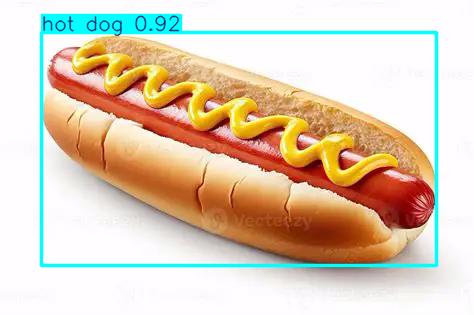

In [1]:
!pip install ultralytics
import ultralytics
from ultralytics import YOLO
# Load a tiny pre-trained model
yolo_model = YOLO("yolov8n.pt") # n = nano (fast, small)
# Run detection on your hot dog image (using a URL now)
results = yolo_model("https://tse3.mm.bing.net/th/id/OIP.AhG6YHrGw9dcdDUCC19QqgHaE7?r=0&rs=1&pid=ImgDetMain&o=7&rm=3")
# Show results (it will draw boxes around objects it recognizes)
results[0].show()